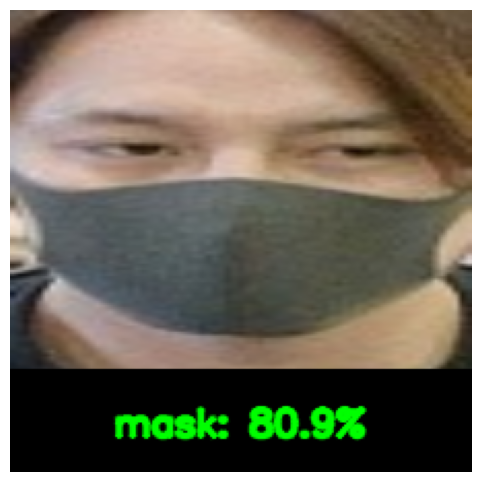

In [8]:
import os
import cv2
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
from torchvision import transforms
import torchvision.models as models
import matplotlib.pyplot as plt

# 1. Setup Device and Constants
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PTH_PATH = "../models/drowsiness-detection.pth"
IMAGE_PATH = "../data/processed/test/masked/with_mask (3).png" 

CLASS_NAMES = ["mask", "unmasked"] 
NUM_CLASSES = len(CLASS_NAMES)

# 2. Load Model
model = models.resnet18()
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model.load_state_dict(torch.load(PTH_PATH, map_location=device))
model = model.to(device)
model.eval()

# 3. Preprocess for Inference (Keep as 224x224 for the model)
preprocess = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])
original_frame = cv2.imread(IMAGE_PATH)
rgb_frame = cv2.cvtColor(original_frame, cv2.COLOR_BGR2RGB)
pil_img = Image.fromarray(rgb_frame)
input_tensor = preprocess(pil_img).unsqueeze(0).to(device)

# 4. Run Inference
with torch.no_grad():
    outputs = model(input_tensor)
    confidence, predicted_idx = torch.max(torch.nn.functional.softmax(outputs[0], dim=0), 0)
    label = CLASS_NAMES[predicted_idx.item()]
    score = confidence.item() * 100

# 5. Create a 224x224 canvas with image on top and text below
padding_height = 50
img_size = 224
# Resize original image to leave space for padding
resized_img = cv2.resize(original_frame, (img_size, img_size - padding_height))

# Create black 224x224 canvas
final_canvas = np.zeros((img_size, img_size, 3), dtype=np.uint8)
# Paste resized image at the top
final_canvas[0:img_size - padding_height, 0:img_size] = resized_img

# 6. UI Overlay
color = (0, 255, 0) if predicted_idx.item() == 0 else (0, 0, 255)
display_text = f"{label}: {score:.1f}%"

font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 0.6
thickness = 2
(text_width, text_height), _ = cv2.getTextSize(display_text, font, font_scale, thickness)

# Position text in the center of the bottom padding
text_x = (img_size - text_width) // 2
text_y = (img_size - padding_height) + (padding_height + text_height) // 2

cv2.putText(final_canvas, display_text, (text_x, text_y), font, font_scale, color, thickness, cv2.LINE_AA)

# 7. Display
plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(final_canvas, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()